In [1]:
import importlib
import numpy as np
import sklearn
from matplotlib import pyplot as plt
from os.path import join
import os
import seaborn as sns
from pandas.core.ops import comparison_op
from torchvision.ops.misc import interpolate
from tqdm.notebook import tqdm as tqdm_notebook

#### Custum libraries
import lib.algos_maxRSA as max_rsa
import lib.utils_RSA as rsa
import lib.utils_CKA as cka
from lib.algos import *
from scipy.spatial import procrustes as scipro

from lib.algos_maxRSA import find_max_dissimilarity_images

importlib.reload(rsa)
importlib.reload(cka)
importlib.reload(max_rsa)

<module 'lib.algos_maxRSA' from '/home/alban/projects/SAYCam_Vs_EGO4D/lib/algos_maxRSA.py'>

In [2]:
rootsavedir = f'figures/compactness_search/'

savedirs = os.listdir(rootsavedir)

modelsets = ['vgg', 'resnet', 'ohran']
metrics = ['R-squared', 'R-squared_adjusted', 'Davies-Bouldin_Index', 'CH_Index', 'simplified_silhouette_score', 'silhouette_score', 'Fisher_discriminant'] #  'CH_Index_adapted',
imagesets = ['genLOC2']

savedirs

['ohran_CH_Index_adapted_genLOC2',
 'vgg_CH_Index_adapted_genLOC2',
 'vgg_simplified_silhouette_score_genLOC2',
 'vgg_R-squared_genLOC2',
 'resnet_Davies-Bouldin_Index_genLOC2',
 'vgg_R-squared_adjusted_genLOC2',
 'resnet_CH_Index_adapted_genLOC2',
 'resnet_silhouette_score_genLOC2',
 'ohran_R-squared_genLOC2',
 'ohran_R-squared_adjusted_genLOC2',
 'ohran_silhouette_score_genLOC2',
 'resnet_simplified_silhouette_score_genLOC2',
 'vgg_CH_Index_genLOC2',
 'ohran_CH_Index_genLOC2',
 'resnet_R-squared_genLOC2',
 'resnet_Fisher_discriminant_genLOC2',
 'ohran_simplified_silhouette_score_genLOC2',
 'vgg_Fisher_discriminant_genLOC2',
 'ohran_Fisher_discriminant_genLOC2',
 'ohran_Davies-Bouldin_Index_genLOC2',
 'resnet_CH_Index_genLOC2',
 'vgg_silhouette_score_genLOC2',
 'resnet_R-squared_adjusted_genLOC2',
 'vgg_Davies-Bouldin_Index_genLOC2']

In [4]:
# creating dataframe
comparison_list = list() ; metrics_list = list() ; imagesets_list = list() ; exectution_times = list(); similarity_score_comp = list(); similarity_score_comb = list()

selected_categories_comp = {}
selected_categories_comb = {}

import pickle
for ms, modelset in enumerate(modelsets):
    selected_categories_comp[modelset] = {}
    selected_categories_comb[modelset] = {}
    for m, metric in enumerate(metrics):
        selected_categories_comp[modelset][metric] = {}
        selected_categories_comb[modelset][metric] = {}
        for ims, imageset in enumerate(imagesets):
            geeky_file = open(join(rootsavedir,f'{modelset}_{metric}_{imageset}/results.pkl'), 'rb')
            stats = pickle.load(geeky_file)
            selected_categories_comp[modelset][metric][imageset] = {}
            selected_categories_comb[modelset][metric][imageset] = {}
            for vs, model_comparison in enumerate(stats['similarities_compact']):
                comparison_list.append(model_comparison)
                metrics_list.append(metric.replace('_', ' '))
                imagesets_list.append(imageset)
                exectution_times.append(stats['execution_time'])#
                similarity_score_comp.append(stats['similarities_compact'][model_comparison])
                similarity_score_comb.append(stats['similarities_corr_compact'][model_comparison])
                #selected_categories_comp[modelset][metric][imageset][model_comparison] = stats['selected_categories_comp'][model_comparison]
                #selected_categories_comb[modelset][metric][imageset][model_comparison] = stats['selected_categories'][model_comparison]

import pandas as pd
df = pd.DataFrame({'Comparison': comparison_list, 'Metric': metrics_list, 'Imageset': imagesets_list, 'Execution time': exectution_times, 'Similarity compact only': similarity_score_comp, 'Similarity score': similarity_score_comb})
print(df)


            Comparison               Metric Imageset  Execution time  \
0           faces_dual            R-squared  genLOC2        1.219747   
1        faces_objects            R-squared  genLOC2        1.219747   
2         faces_random            R-squared  genLOC2        1.219747   
3         dual_objects            R-squared  genLOC2        1.219747   
4          dual_random            R-squared  genLOC2        1.219747   
..                 ...                  ...      ...             ...   
184    imagenet_resnet  Fisher discriminant  genLOC2       82.867799   
185    imagenet_random  Fisher discriminant  genLOC2       82.867799   
186  supervised_resnet  Fisher discriminant  genLOC2       82.867799   
187  supervised_random  Fisher discriminant  genLOC2       82.867799   
188      resnet_random  Fisher discriminant  genLOC2       82.867799   

     Similarity compact only  Similarity score  
0                   0.085086          0.004723  
1                   0.042342         

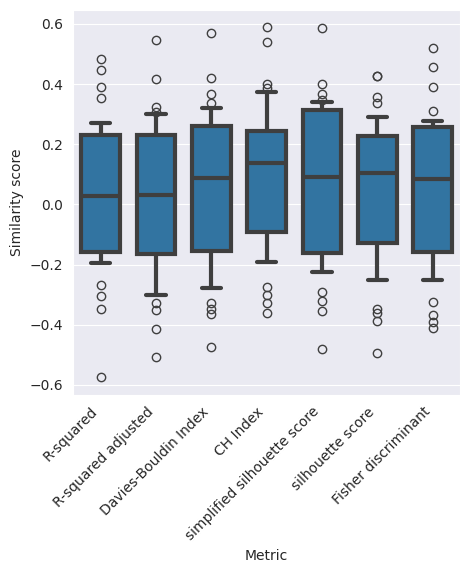

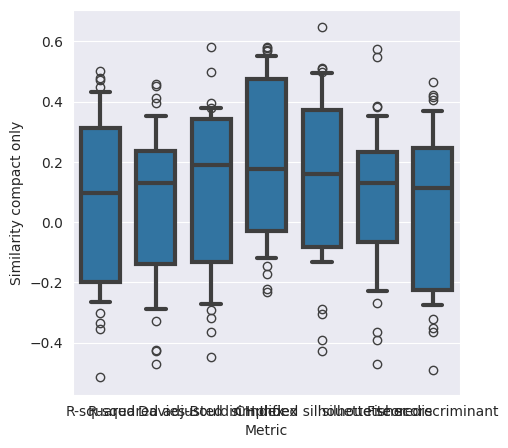

In [16]:
fig, subs = plt.subplots(1,1, figsize = (5, 5))
ax1 = sns.boxplot(data=df, y='Similarity score', x="Metric", whis=(15, 85), linewidth=3,width=.7)
plt.xticks(rotation=45, ha='right')
plt.show()
plt.close()

fig, subs = plt.subplots(1,1, figsize = (5, 5))
sns.boxplot(data=df, y='Similarity compact only', x="Metric", whis=(15, 85), linewidth=3, width=.7)
plt.show()
plt.close()

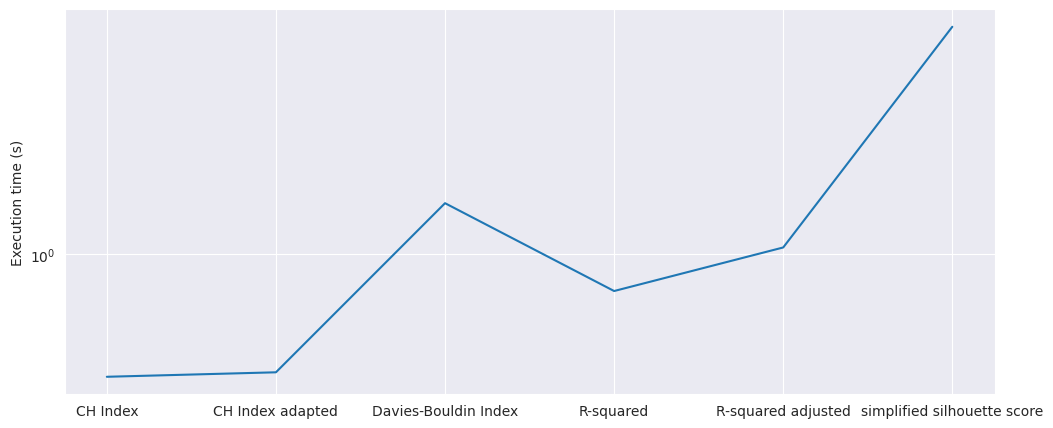

In [6]:
means_execution = df.groupby('Metric')['Execution time'].mean()
fig, subs = plt.subplots(1,1, figsize = (12, 5))
subs.semilogy(means_execution)
subs.set_ylabel('Execution time (s)')
plt.show()
plt.close()

/tmp/ipykernel_6659/3471990064.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_6659/3471990064.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


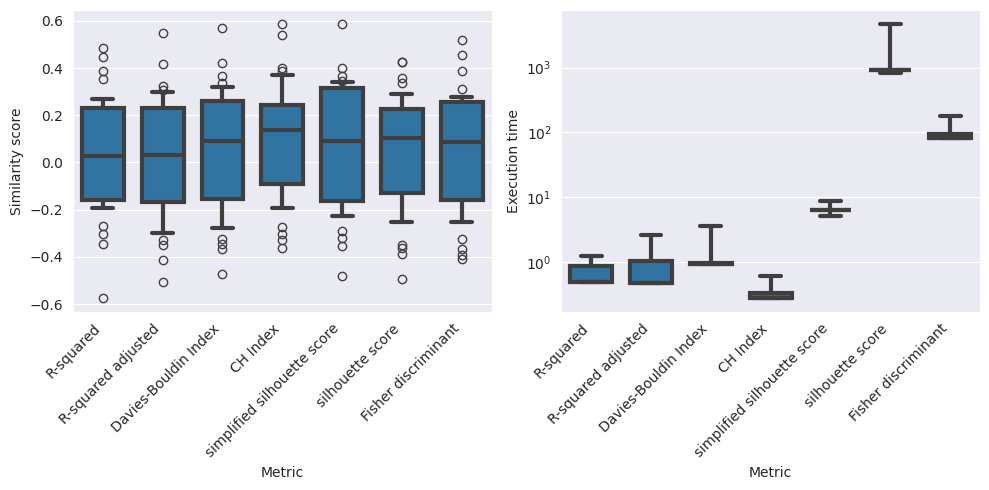

In [24]:
fig, subs = plt.subplots(1,2, figsize = (10, 5))
sns.boxplot(data=df, y='Similarity score', x="Metric", whis=(15, 85), linewidth=3,width=.7, ax=subs[0])
sns.boxplot(data=df, y='Execution time', x="Metric", whis=(15, 85), linewidth=3, log_scale=True, width=.7, ax=subs[1])
for ax in subs:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()
fig.savefig(join(rootsavedir,'compactness_search.png'))
plt.close()

In [8]:
selected_categories_comp['vgg']['CH_Index_adapted']['genLOC2']
selected_categories_comp['resnet']['CH_Index_adapted']['genLOC2']

{'faces_places': array(['2870_cauldron', '0359_shovel', '2002_wand', '0333_corn',
        '2585_pickle', '0955_cane', '0754_clarinet', '1635_paintbrush',
        '0836_chalk', '0875_broom', '0238_tent', '1745_earwig'],
       dtype='<U18'),
 'faces_imagenet': array(['1745_earwig', '1063_knot', '0511_needle', '1840_tray',
        '0754_clarinet', '0131_wall', '0955_cane', '1923_squeegee',
        '0038_book', '0675_toothpick', '1848_gecko', '1026_condom'],
       dtype='<U18'),
 'faces_random0': array(['0235_telescope', '0148_cat', '1551_coconut', '0607_crate',
        '1745_earwig', '0111_doll', '2796_tyrannosaurus', '1848_gecko',
        '0272_walrus', '1282_parsnip', '0062_table', '0262_binoculars'],
       dtype='<U18'),
 'places_imagenet': array(['1063_knot', '0359_shovel', '2870_cauldron', '0740_worm',
        '0875_broom', '0215_axe', '2651_tapioca', '1635_paintbrush',
        '1840_tray', '1468_banner', '1572_chocolate', '1120_tunnel'],
       dtype='<U18'),
 'places_random0': a

In [13]:
selected_categories_comb['vgg']['CH_Index_adapted']['genLOC2']

{'faces_dual': array(['0828_pea', '2212_manhole', '0047_fire', '2467_compass',
        '2658_birdcage', '0082_kitchen', '0361_bucket', '0334_cave',
        '0001_man', '0464_lime', '1003_nest', '0842_bicycle'], dtype='<U18'),
 'faces_objects': array(['0828_pea', '1348_cucumber', '0001_man', '1120_tunnel',
        '2212_manhole', '0082_kitchen', '0361_bucket', '2400_geyser',
        '0056_child', '0718_cumin', '2467_compass', '0659_carousel'],
       dtype='<U18'),
 'faces_random': array(['2460_macadamia', '1433_tower', '1025_newspaper', '1385_doormat',
        '0359_shovel', '1082_caterpillar', '1206_anteater', '1739_burlap',
        '1063_knot', '0220_mailbox', '0292_lion', '2377_shield'],
       dtype='<U18'),
 'dual_objects': array(['1512_chili', '0047_fire', '0423_violin', '1724_okra', '1593_wire',
        '0334_cave', '0853_wheat', '1101_crayon', '1536_celery',
        '1235_mistletoe', '1264_mantis', '0686_coliseum'], dtype='<U18'),
 'dual_random': array(['2460_macadamia', '1120_